# MELAGE Python API — quick tour

This notebook walks through MELAGE's headless **Python API** (`melage.api`, exposed at the top level as `melage`): loading an image, preprocessing, segmentation, saving results, 2-D slice plots, and a quick headless **3-D visualization**.

No GUI / Qt / OpenGL display is required — everything here also works from a plain shell script.

We use the bundled MNI ICBM152 template that ships with the repo under `data/MNI/`.

In [1]:
import os
import sys

# Make sure we import THIS repo's copy of melage (with the new `melage.api` /
# `melage.visualize` modules) rather than any older version that may already
# be installed in the environment. Run this notebook from the `example/`
# folder (Jupyter's default cwd) so `..` resolves to the repo root.
_repo_root = os.path.abspath("..")
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import matplotlib.pyplot as plt
import melage

print("melage module path:", melage.__file__)
print("MELAGE version:", melage.__version__)
print("Available tools:", melage.list_tools())

Using Shaders_330


/home/binibica/venv/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


melage module path: /home/binibica/MELAGE/MELAGE/melage/__init__.py
MELAGE version: 2.1.34
Available tools: ['bet', 'brain_extraction', 'fcm', 'largest_cc', 'n4', 'n4_bias', 'normalize', 'preprocess_and_bet', 'resample', 'resize', 'threshold', 'tissue_seg']


## 1. Load an image

`melage.load` returns a `Volume` — a lightweight wrapper around a NIfTI image (numpy data + affine + header) plus an optional segmentation array.

In [2]:
DATA_DIR = os.path.join("..", "data", "MNI")
image_path = os.path.join(DATA_DIR, "mni_icbm152_t1_tal_nlin_sym_09a.nii")

vol = melage.load(image_path)
vol  # Jupyter-friendly HTML repr: shape, spacing, dtype, intensity range, ...

Volume(shape=(189, 233, 197), spacing=(1.00,1.00,1.00) mm, dtype=float64)

In [3]:
# melage.info() prints metadata straight from disk — no full load needed
melage.info(image_path)

File   : ../data/MNI/mni_icbm152_t1_tal_nlin_sym_09a.nii
Format : NIfTI
Shape  : (197, 233, 189)
Spacing: 1.000 × 1.000 × 1.000 mm
Dtype  : int16


{'path': '../data/MNI/mni_icbm152_t1_tal_nlin_sym_09a.nii',
 'format': 'NIfTI',
 'shape': (197, 233, 189),
 'spacing_mm': (1.0, 1.0, 1.0),
 'dtype': dtype('<i2'),
 'affine': array([[   1.,    0.,    0.,  -98.],
        [   0.,    1.,    0., -134.],
        [   0.,    0.,    1.,  -72.],
        [   0.,    0.,    0.,    1.]])}

## 2. Preprocessing

All `melage.preprocess.*` functions take a `Volume` and return a new `Volume` (functional style — the input is never mutated). Pass `progress=False` to silence the textual progress output in notebooks.

In [4]:
# `shrink_factor` down-samples the image before estimating the bias field —
# a standard speed/quality trade-off that keeps this demo fast on a laptop
# while still producing a good correction (the field is then applied at
# full resolution).
vol_n4 = melage.preprocess.n4_bias(vol, shrink_factor=4, progress=False)
vol_rs = melage.preprocess.resize(vol_n4, spacing=2.0, progress=False)
vol_norm = melage.preprocess.normalize(vol_rs, progress=False)

vol_norm

Volume(shape=(94, 116, 98), spacing=(2.00,2.00,2.00) mm, dtype=float32)

## 3. Segmentation

`melage.segment.bet` runs brain extraction and stores the resulting binary mask in `vol.segmentation`.

In [5]:
# `iterations` controls how many surface-deformation steps BET runs; the
# default (1000) gives the most accurate mask but is slow on a full notebook
# run, so we use a smaller value here purely to keep this demo quick.
vol_seg = melage.segment.bet(vol_norm, progress=False, iterations=60)
print("Segmentation labels present:", sorted(set(vol_seg.segmentation.ravel().tolist())))
vol_seg

Brain extractor initialization complete!
Segmentation labels present: [0, 1]


Volume(shape=(94, 116, 98), spacing=(2.00,2.00,2.00) mm, dtype=float32, seg_labels=1)

## 4. Plot 2-D slices

`Volume.data` and `Volume.segmentation` are plain numpy arrays — plug them straight into matplotlib.

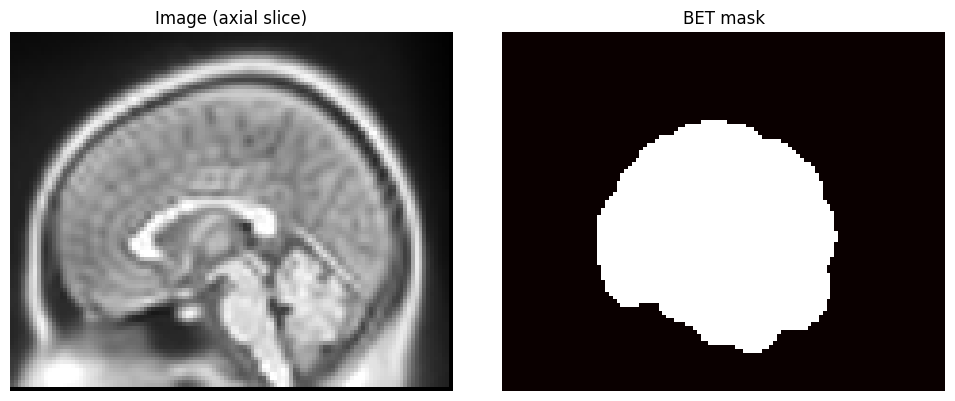

In [6]:
mid = vol_seg.shape[2] // 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(vol_seg.data[:, :, mid], cmap="gray")
ax1.set_title("Image (axial slice)")
ax2.imshow(vol_seg.segmentation[:, :, mid], cmap="hot")
ax2.set_title("BET mask")
for ax in (ax1, ax2):
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Headless 3-D visualization

MELAGE's interactive 3-D viewer (`glScientific`) needs a live Qt/OpenGL display. `melage.visualize` provides two headless ways to render: a lightweight default built on `skimage.measure.marching_cubes` + `matplotlib` / `trimesh` (`engine="mesh"`, used below), and `engine="gl"`, which drives the *real* `glScientific` OpenGL ray-caster offscreen — see §5b.

- `melage.visualize.render(vol, label=...)` → matplotlib 3-D figure
- `melage.visualize.screenshot(vol, path, ...)` → render straight to PNG/JPG
- `melage.visualize.mesh(vol, label=...)` → `trimesh.Trimesh` surface mesh
- `melage.visualize.export_mesh(vol, path, ...)` → write a mesh file (`.stl`, `.obj`, `.ply`, ...)

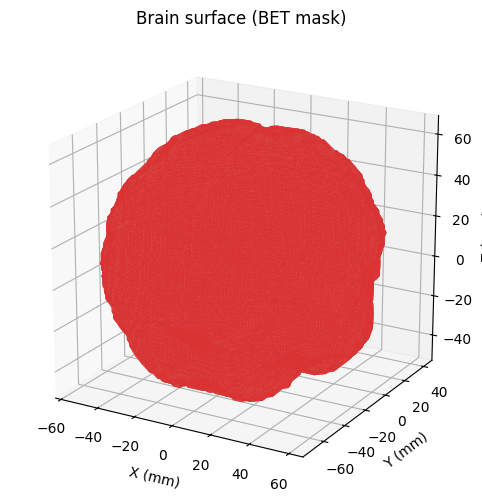

In [7]:
fig = melage.visualize.render(vol_seg, label=1, title="Brain surface (BET mask)")
plt.show()

In [8]:
# Save a screenshot and export the surface as an STL mesh for use in other tools
out_dir = "output"
os.makedirs(out_dir, exist_ok=True)

melage.visualize.screenshot(vol_seg, os.path.join(out_dir, "brain_3d.png"), label=1, elev=15, azim=45)
melage.visualize.export_mesh(vol_seg, os.path.join(out_dir, "brain.stl"), label=1, smooth=True)

print("Wrote:", os.listdir(out_dir))

Wrote: ['brain_3d.png', 'brain_3d_toolbar.png', 'brain_3d_gl.png', 'brain.stl', 'brain_3d_overlay.png']


### 5b. GPU-accelerated headless rendering (`engine="gl"`)

`render` / `screenshot` also accept `engine="gl"`, which reuses MELAGE's **real OpenGL volume ray-caster** (`glScientific` — the same renderer behind the GUI's interactive 3-D viewer) instead of the marching-cubes/matplotlib path above. It's driven offscreen via Qt's `offscreen` platform plugin, so it runs without a visible display while still using hardware-accelerated OpenGL — no GUI window ever appears.

This gives you the GUI's actual volumetric rendering (camera elevation/azimuth, colormaps, etc.) straight from a script or notebook. If PyQt5/OpenGL/a GPU isn't available, it automatically falls back to `engine="mesh"` with a warning — so this code path is always safe to call.

QPainter::begin: Paint device returned engine == 0, type: 1
QPainter::setRenderHint: Painter must be active to set rendering hints
QPainter::setFont: Painter not active
QPainter::setPen: Painter not active
QPainter::end: Painter not active, aborted


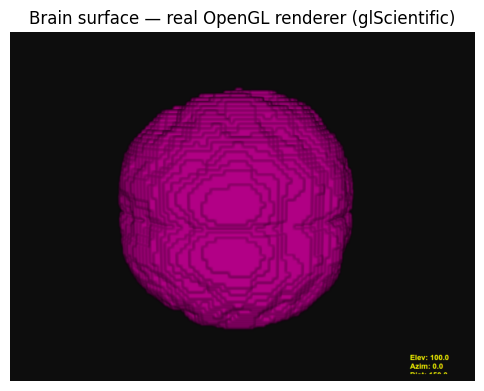

Wrote: output/brain_3d_gl.png


In [9]:
# Same `vol_seg`, same `label=1` — just a different renderer under the hood.
# `cmap` selects a matplotlib colormap for the volume; `elev`/`azim` set the
# camera, exactly like the mesh engine above.
fig_gl = melage.visualize.render(
    vol_seg, label=1, engine="gl", cmap="gist_rainbow",
    elev=100, azim=360, title="Brain surface — real OpenGL renderer (glScientific)", distance=150
)
plt.show()

melage.visualize.screenshot(
    vol_seg, os.path.join(out_dir, "brain_3d_gl.png"),
    label=1, engine="gl", cmap="gist_rainbow", elev=20, azim=-20
)
print("Wrote:", os.path.join(out_dir, "brain_3d_gl.png"))

### 5c. Image + segmentation overlay (`overlay=True`)

Pass `overlay=True` (with `engine="gl"`) to render the grayscale image with the
(coloured) segmentation alpha-blended on top — the same **"Show Img+Seg"** mode
available in the GUI's interactive 3-D view (`glScientific.paint` /
`updateSegVolItem`), driven headlessly. `cmap` is ignored in this mode; labels
get MELAGE's standard palette (or restrict to specific ones with `label=...`).

`alpha` controls the segmentation overlay's opacity: `0` = invisible (image
only), `1` = fully opaque (default). Values in between — e.g. `0.5` below —
blend the coloured overlay with the underlying anatomy so both remain visible.

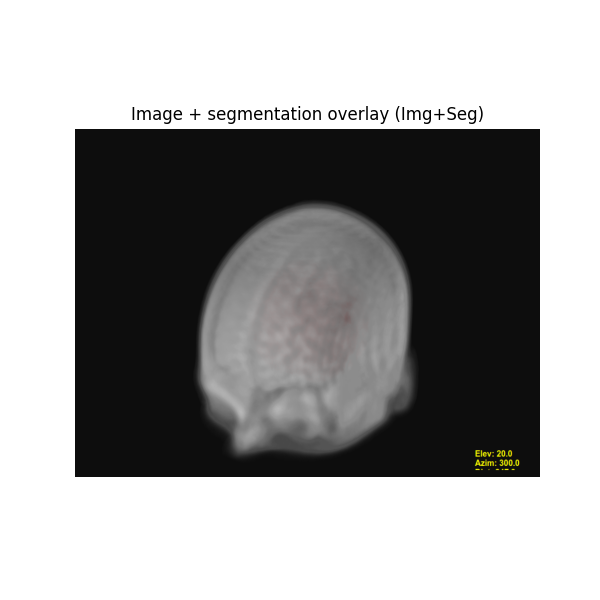

Wrote: output/brain_3d_overlay.png


In [10]:
fig_overlay = melage.visualize.render(
    vol_seg, label=1, engine="gl", overlay=True, alpha=0.5,
    elev=20, azim=-60, title="Image + segmentation overlay (Img+Seg)",
)
plt.show()

melage.visualize.screenshot(
    vol_seg, os.path.join(out_dir, "brain_3d_overlay.png"),
    label=1, engine="gl", overlay=True, alpha=0.5, elev=20, azim=-60,
)
print("Wrote:", os.path.join(out_dir, "brain_3d_overlay.png"))

### 5d. 3-D toolbar options (`engine="gl"`)

`render`/`screenshot` with `engine="gl"` also expose the same controls as the GUI's 3-D
toolbar / right-click menu:

- `bgcolor=(r, g, b, a)` — background colour (0-1), e.g. white `(1, 1, 1, 1)`
- `axis=True` / `grid=True` — show the axis triad / background grid
- `threshold=0-100` — voxel-intensity cutoff (percent of max), masks out dim voxels
- `cut="cut_remove_half_action"` — clip away part of the volume (see
  `glScientific`'s "Clipping (Cut)" menu for the full list of action names)
- `view="axial" | "sagittal" | "coronal"` — standard anatomical views, instead of
  setting `elev`/`azim` manually

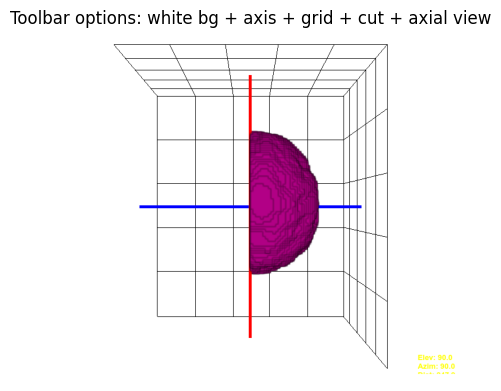

Wrote: output/brain_3d_toolbar.png


In [11]:
fig_toolbar = melage.visualize.render(
    vol_seg, label=1, engine="gl", cmap="gist_rainbow",
    bgcolor=(1, 1, 1, 1), axis=True, grid=True,
    cut="cut_remove_half_action", view="axial",
    title="Toolbar options: white bg + axis + grid + cut + axial view",
)
plt.show()

melage.visualize.screenshot(
    vol_seg, os.path.join(out_dir, "brain_3d_toolbar.png"),
    label=1, engine="gl", cmap="gist_rainbow",
    bgcolor=(1, 1, 1, 1), axis=True, grid=True,
    cut="cut_remove_half_action", view="axial",
)
print("Wrote:", os.path.join(out_dir, "brain_3d_toolbar.png"))

## 6. Save results

Save the processed image and/or its segmentation back to disk as NIfTI.

In [ ]:
melage.save(vol_seg, os.path.join(out_dir, "corrected.nii.gz"))               # processed image
melage.save(vol_seg, os.path.join(out_dir, "brain_mask.nii.gz"), what="seg")  # segmentation

print("Wrote:", sorted(os.listdir(out_dir)))

## 7. Config-driven pipeline (bonus)

`melage.run(tool, vol, **kwargs)` dispatches a processing step by name — handy for looping over a subject list with a declarative pipeline definition.

In [ ]:
pipeline = [
    ("n4_bias",   {"shrink_factor": 4}),    # down-sample for speed during bias-field estimation
    ("resize",    {"spacing": 2.0}),
    ("normalize", {}),
    ("bet",       {"fractional_threshold": 0.45, "iterations": 60}),  # iterations reduced for demo speed
]

v = melage.load(image_path)
for tool, kwargs in pipeline:
    v = melage.run(tool, v, progress=False, **kwargs)

v

---
That's it! See the **Python API & Scripting** section of the project [README](../README.md) for the full reference, including the `melage run` / `melage tools` / `melage info` command-line interface.